In [1]:
%pip install -q scikit-learn scipy matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Standard visualization setup
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")


def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):

    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        # Label -1 in DBSCAN represents 'noise' points - we'll color these black for contrast
        if label == -1:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color="black",
                s=45,
                alpha=0.85,
                label="noise",
            )
        else:
            # Cycle through the color palette for each discovered cluster
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color=palette(color_index % 10),
                s=45,
                alpha=0.85,
                label=f"cluster {label}",
            )
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)


def silhouette_details(features, labels):
    """Calculates per-sample silhouette scores and the overall mean for evaluation."""
    unique_labels = np.unique(labels)
    # We need at least 2 clusters to compute a silhouette score
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)


def describe_clustering(features, labels, model_name):
    """Bundles clustering metrics into a dictionary for easy logging in a DataFrame."""
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores


def estimate_eps_from_k_distance(sorted_distances):
    """
    Heuristic to find the 'elbow' in the K-distance plot.
    It finds the point with the maximum perpendicular distance from a line
    connecting the start and end of the curve.
    """
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))

    start = points[0]
    end = points[-1]
    line_vector = end - start
    line_vector = line_vector / np.linalg.norm(line_vector)

    # Project every point onto the line to find the curve's 'sharpest' turn
    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)

    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index

In [3]:
from sklearn.datasets import make_blobs

X_syn, y_syn = make_blobs(
    n_samples=[120, 110, 130, 90],
    centers=[(-7, -2), (-1, 4.5), (4.5, -4), (7, 4)],
    cluster_std=[1.0, 0.8, 1.1, 0.7],
    random_state=42,
)

syn_df = pd.DataFrame(X_syn, columns=["feature_1", "feature_2"])
print("Synthetic dataset shape:", X_syn.shape)
display(syn_df.head())


Synthetic dataset shape: (450, 2)


,feature_1,feature_2
0,6.5626,4.0183
1,-6.4850,-1.4862
2,4.6093,-3.1735
3,6.5710,3.7286
4,7.4954,3.6063


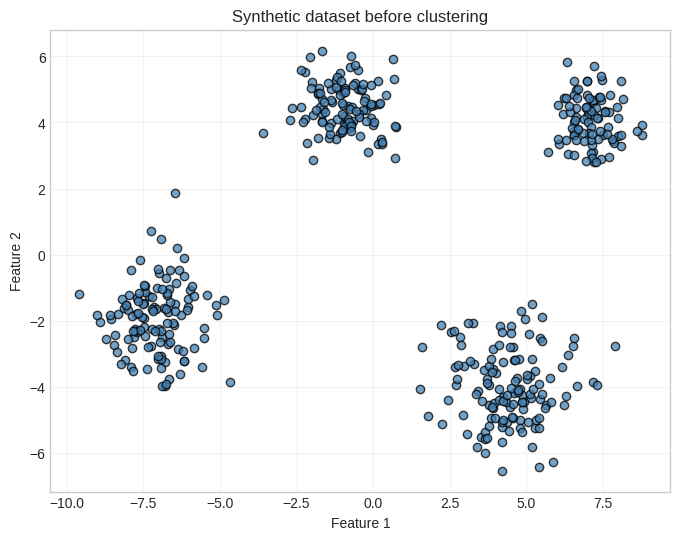

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X_syn[:, 0], X_syn[:, 1], color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Synthetic dataset before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.25)
plt.show()


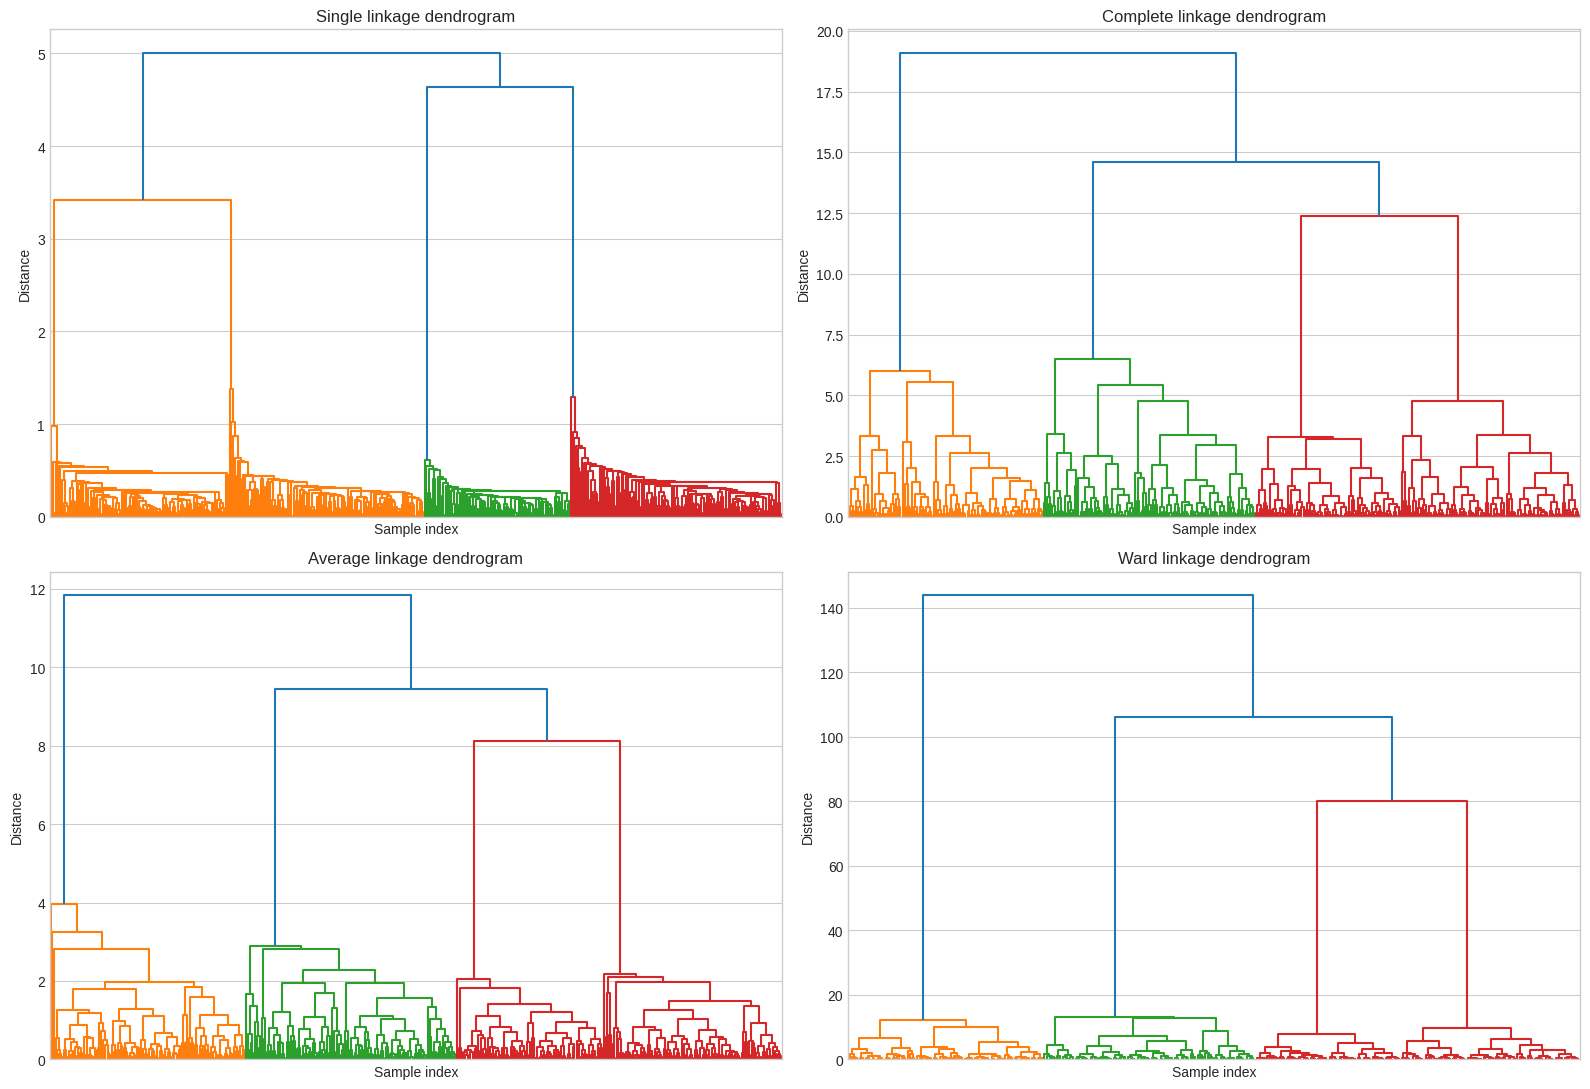

In [5]:
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_syn, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()


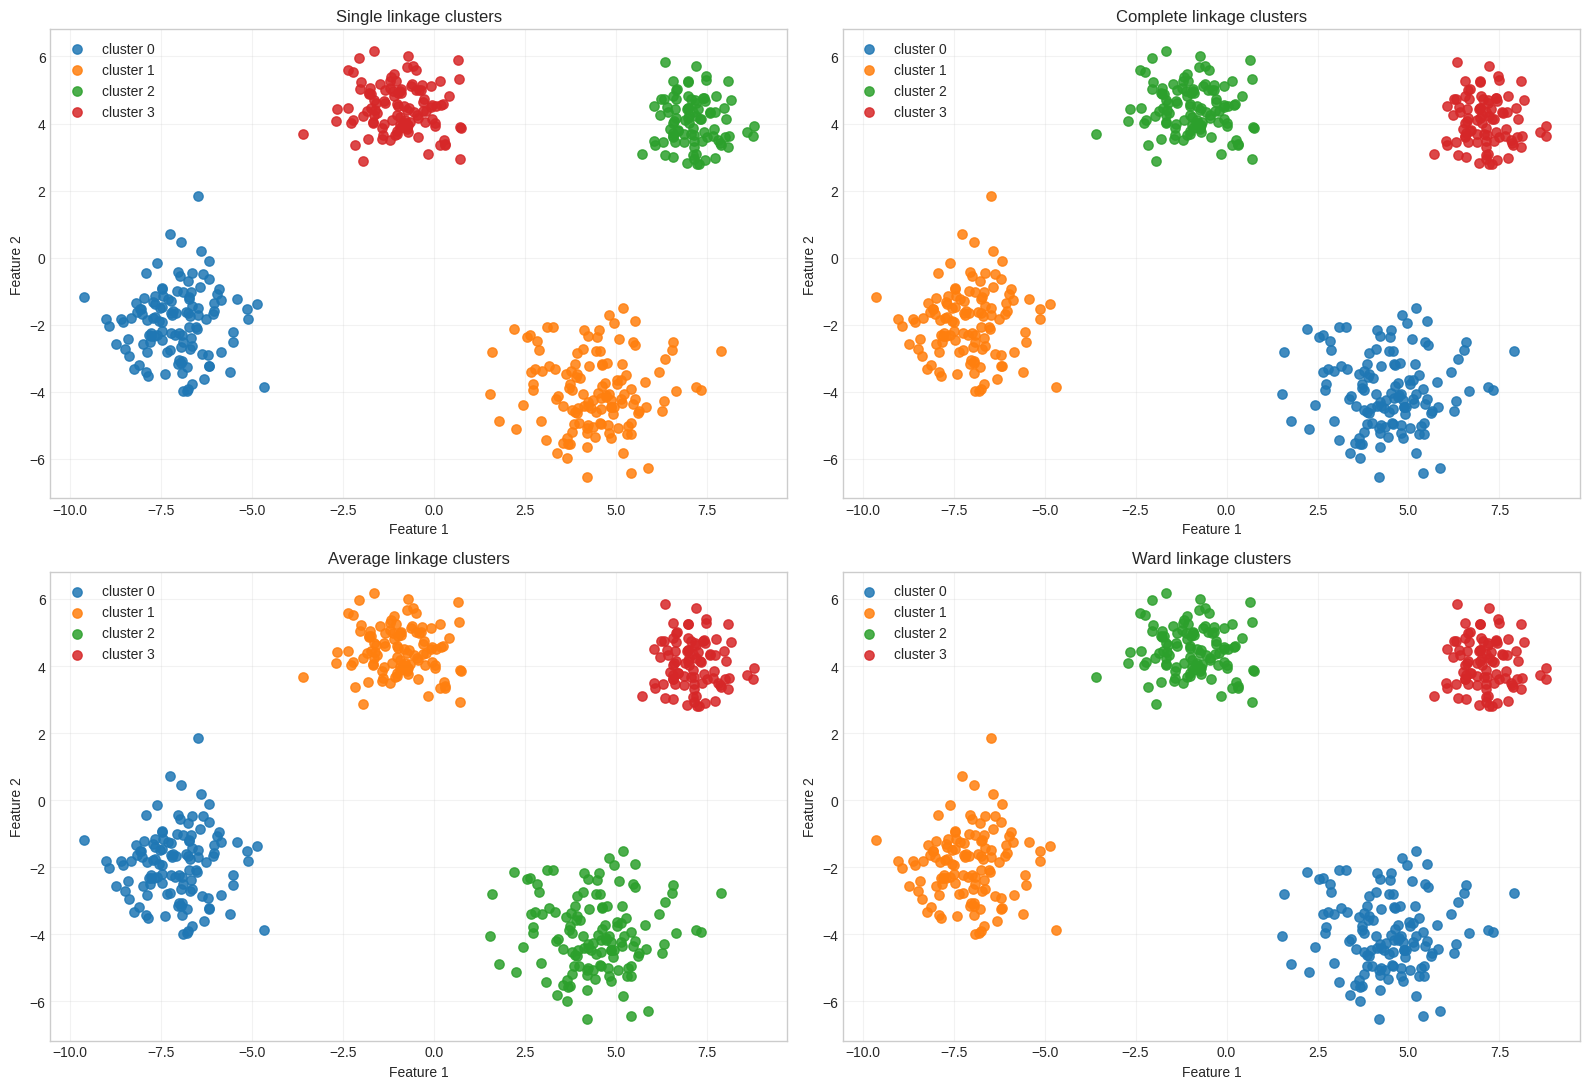

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057


In [6]:
hierarchical_rows = []
hierarchical_sample_scores = {}
hierarchical_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_syn)

    hierarchical_labels[method] = labels
    plot_cluster_map(
        X_syn,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Feature 1",
        y_label="Feature 2",
    )

    row, sample_scores = describe_clustering(
        X_syn,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows.append(row)
    hierarchical_sample_scores[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

hierarchical_results = pd.DataFrame(hierarchical_rows).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results)


In [7]:
hierarchical_silhouette_df = pd.DataFrame(hierarchical_sample_scores)
display(hierarchical_silhouette_df.head(10))
display(hierarchical_silhouette_df.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.8697,0.8697,0.8697,0.8697
1,0.8281,0.8281,0.8281,0.8281
2,0.7870,0.7870,0.7870,0.7870
3,0.8651,0.8651,0.8651,0.8651
4,0.8772,0.8772,0.8772,0.8772
5,0.8750,0.8750,0.8750,0.8750
6,0.8497,0.8497,0.8497,0.8497
7,0.5098,0.5098,0.5098,0.5098
8,0.8696,0.8696,0.8696,0.8696
9,0.8265,0.8265,0.8265,0.8265


,mean,min,max
single_sample_silhouette,0.8057,0.3589,0.8936
complete_sample_silhouette,0.8057,0.3589,0.8936
average_sample_silhouette,0.8057,0.3589,0.8936
ward_sample_silhouette,0.8057,0.3589,0.8936


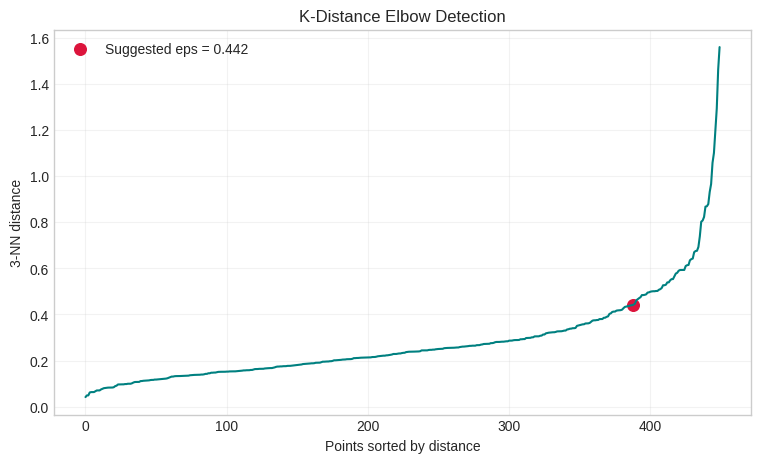

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.243,33,169,-0.1590,0.243
1,DBSCAN eps=0.288,23,115,-0.0665,0.288
2,DBSCAN eps=0.332,19,84,0.0580,0.332
3,DBSCAN eps=0.376,15,68,0.0470,0.376
4,DBSCAN eps=0.42,12,47,0.1224,0.420
5,DBSCAN eps=0.464,11,37,0.3147,0.464
6,DBSCAN eps=0.509,6,31,0.5075,0.509
7,DBSCAN eps=0.553,4,24,0.7287,0.553
8,DBSCAN eps=0.597,4,16,0.7491,0.597
9,DBSCAN eps=0.641,4,10,0.7601,0.641


In [8]:
#  Finding the right Epsilon for DBSCAN

# A good starting point for min_samples is dimensions + 1
min_samples_syn = X_syn.shape[1] + 1

# Use NearestNeighbors to see how far away each point's neighbors are
nn_model_syn = NearestNeighbors(n_neighbors=min_samples_syn)
distances_syn, _ = nn_model_syn.fit(X_syn).kneighbors(X_syn)
k_distances_syn = np.sort(distances_syn[:, -1])

# Identify where the curve 'breaks' - that's usually our best epsilon candidate
suggested_eps_syn, elbow_index_syn = estimate_eps_from_k_distance(k_distances_syn)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_syn, color="teal")
plt.scatter(
    elbow_index_syn,
    k_distances_syn[elbow_index_syn],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_syn:.3f}",
)
plt.title("K-Distance Elbow Detection")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_syn}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# We'll search around that suggested value to refine the choice
eps_candidates_syn = np.unique(
    np.round(
        np.linspace(
            max(0.05, suggested_eps_syn * 0.55),
            suggested_eps_syn * 1.45,
            10,
        ),
        3,
    )
)

# Run DBSCAN for each candidate and log the results
search_rows_syn = []
for eps in eps_candidates_syn:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_syn).fit_predict(X_syn)
    row, _ = describe_clustering(X_syn, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_syn.append(row)

dbscan_search_syn = pd.DataFrame(search_rows_syn)
display(dbscan_search_syn.sort_values(by="eps"))

In [ ]:
valid_dbscan_syn = dbscan_search_syn.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_syn = valid_dbscan_syn[valid_dbscan_syn["cluster_count"] >= 2].copy()

best_dbscan_syn = valid_dbscan_syn.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_syn = float(best_dbscan_syn["eps"])
dbscan_syn = DBSCAN(eps=best_eps_syn, min_samples=min_samples_syn)
dbscan_syn_labels = dbscan_syn.fit_predict(X_syn)

dbscan_syn_row, dbscan_syn_sample_scores = describe_clustering(
    X_syn,
    dbscan_syn_labels,
    model_name=f"DBSCAN (eps={best_eps_syn:.3f}, min_samples={min_samples_syn})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_syn,
    dbscan_syn_labels,
    title=f"DBSCAN clusters on synthetic data (eps={best_eps_syn:.3f})",
    x_label="Feature 1",
    y_label="Feature 2",
)
plt.show()

print("Chosen eps:", round(best_eps_syn, 3))
print("Total noise points found:", dbscan_syn_row["noise_points"])

dbscan_syn_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_syn_labels,
        "sample_silhouette": dbscan_syn_sample_scores,
    }
)

display(pd.DataFrame([dbscan_syn_row]))
display(dbscan_syn_silhouette_df.head(10))
display(dbscan_syn_silhouette_df["sample_silhouette"].describe())


## Final comparison

This makes it easier to compare the average silhouette score from the hierarchical models against the best DBSCAN run on the same dataset.


In [ ]:
synthetic_comparison = pd.concat(
    [
        hierarchical_results,
        pd.DataFrame([dbscan_syn_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

display(synthetic_comparison)


## Short discussion: why DBSCAN can look good but still score lower

DBSCAN can produce clusters that look very natural to a person because it handles shapes that are uneven, stretched out, or separated by low-density gaps.  
Silhouette score is less flexible because it favors clusters that are compact and clearly separated in a more convex way.  
On top of that, DBSCAN labels some border points as noise, and those edge cases can pull the average silhouette down even when the visual clustering still makes sense.
